In [1]:
import numpy as np
from matplotlib import pyplot as plt



# Computing the expected S2 max separation distribution

Let's consider a simplified model where we just consider two vertices separated by an average value of $x_0$, where the separation is drawn from an exponential distribution and the particle is emitted isotropically into $4\pi$. This models a gamma ray traveling away from the site of a beta decay.

Average r (selected) =  35.533688907425265
Average r (selected z > 3.0 mm) =  28.716183145308534
Average r (selected z > 5.0 mm) =  31.009815549748517
Average r (selected z > 10.0 mm) =  35.533688907425265


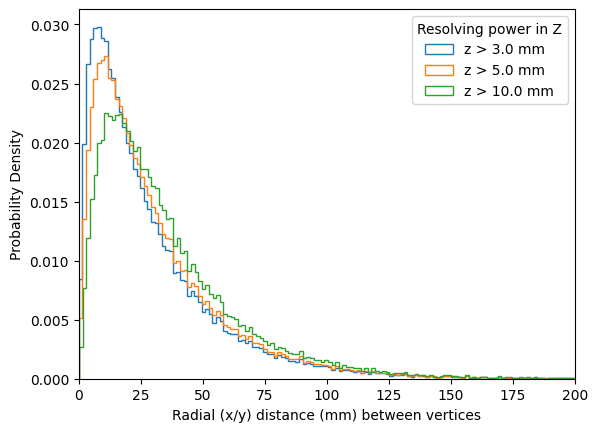

In [20]:
# Sample from an exponential distribution
nevts = 100000

# The scale is say 4cm
scale = 30 # mm
data = np.random.exponential(scale=scale, size=nevts)

# First plot the exponential distribution
# plt.hist(data, bins=200, density=True, alpha=0.6, color='g')
plt.xlabel('Radial (x/y) distance (mm) between vertices')
plt.ylabel('Probability Density')

plt.xlim(0.,200.)
# plt.ylim(0.,0.025)


# For each event, draw a random direction in 3D
theta = np.arccos(1 - 2 * np.random.rand(nevts))
phi = 2 * np.pi * np.random.rand(nevts)
dx = data * np.sin(theta) * np.cos(phi)
dy = data * np.sin(theta) * np.sin(phi)
dz = data * np.cos(theta)

# Now reconstruct the radius in x/y
r = np.sqrt(dx**2 + dy**2)

z_separation = 10.0 # mm

# select only those events that have z > z_separation
selected = np.abs(dz) > z_separation
# plt.hist(r[selected], bins=200, density=True, alpha=0.6, color='b')

# print('Average r (all) = ', np.mean(r))
print('Average r (selected) = ', np.mean(r[selected]))

z_separations = [3.0, 5.0, 10.0]

for z_separation in z_separations:
    selected = np.abs(dz) > z_separation
    plt.hist(r[selected], bins=200, density=True, alpha=1., label=f'z > {z_separation} mm', histtype='step')

    print(f'Average r (selected z > {z_separation} mm) = ', np.mean(r[selected]))

plt.legend(title='Resolving power in Z')







In [ ]:
# Now try drawing multiple vertices per event, and plot the maximum radial distance between two vertices
# for each event
num_vertices = [2, 3, 4, 5]

for nvert in num_vertices:
    